In [37]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.stats import norm

# AAPL

In [38]:
# load the two saved models
xgb_model = joblib.load("xgb_aapl_model.pkl")
nn_model = joblib.load("nn_aapl_model.pkl")
nn_scaler = joblib.load("nn_aapl_scaler.pkl")

print("xgb loaded:", type(xgb_model))
print("xgb expects features:", xgb_model.get_booster().feature_names)

print("nn loaded:", type(nn_model))
print("scaler loaded:", type(nn_scaler))
print("scaler expects", nn_scaler.n_features_in_, "features")

xgb loaded: <class 'xgboost.sklearn.XGBRegressor'>
xgb expects features: ['moneyness (S/K)', 'T', 'rate', 'q', 'volatility']
nn loaded: <class 'sklearn.neural_network._multilayer_perceptron.MLPRegressor'>
scaler loaded: <class 'sklearn.preprocessing._data.StandardScaler'>
scaler expects 5 features


c:\Users\glmar\OneDrive\Bemacs Bocconi\TESI\Thesis\Priced-by-intelligence\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\glmar\OneDrive\Bemacs Bocconi\TESI\Thesis\Priced-by-intelligence\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [39]:
# synthetic grid v2: fix S at a realistic level, vary K to obtain moneyness
S_fixed = 200.0        # realistic AAPL level in the sample
T_fixed = 0.194521
r_fixed = 0.008786
q_fixed = 0.004492
sigma_fixed = 0.281015

moneyness_grid = np.linspace(0.3, 20, 400)
K_grid = S_fixed / moneyness_grid      # K varies to produce the moneyness grid

train_boundary = 5.3   # 99th percentile of training moneyness (effective training limit)

print("grid shape:", moneyness_grid.shape)
print("moneyness range:", moneyness_grid.min(), "to", moneyness_grid.max())

grid shape: (400,)
moneyness range: 0.3 to 20.0


In [40]:
# Black-Scholes on the corrected grid
d1 = (np.log(S_fixed / K_grid) + (r_fixed - q_fixed + 0.5 * sigma_fixed**2) * T_fixed) / (sigma_fixed * np.sqrt(T_fixed))
d2 = d1 - sigma_fixed * np.sqrt(T_fixed)
bs_price = S_fixed * np.exp(-q_fixed * T_fixed) * norm.cdf(d1) - K_grid * np.exp(-r_fixed * T_fixed) * norm.cdf(d2)
bs_price_norm = bs_price / K_grid

In [41]:
X_grid_xgb = pd.DataFrame({
    "moneyness (S/K)": moneyness_grid, "T": T_fixed, "rate": r_fixed,
    "q": q_fixed, "volatility": sigma_fixed
})
xgb_pred_norm = np.exp(xgb_model.predict(X_grid_xgb))   # exp(log(C/K)) = C/K directly
xgb_pred_price = xgb_pred_norm * K_grid                  # back to dollars, if needed

In [42]:
X_grid_nn = pd.DataFrame({
    "moneyness (S/K)": moneyness_grid, "T": T_fixed, "rate": r_fixed,
    "q": q_fixed, "volatility": sigma_fixed
})
X_grid_nn_scaled = nn_scaler.transform(X_grid_nn)
nn_pred_norm = np.exp(nn_model.predict(X_grid_nn_scaled))

c:\Users\glmar\OneDrive\Bemacs Bocconi\TESI\Thesis\Priced-by-intelligence\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


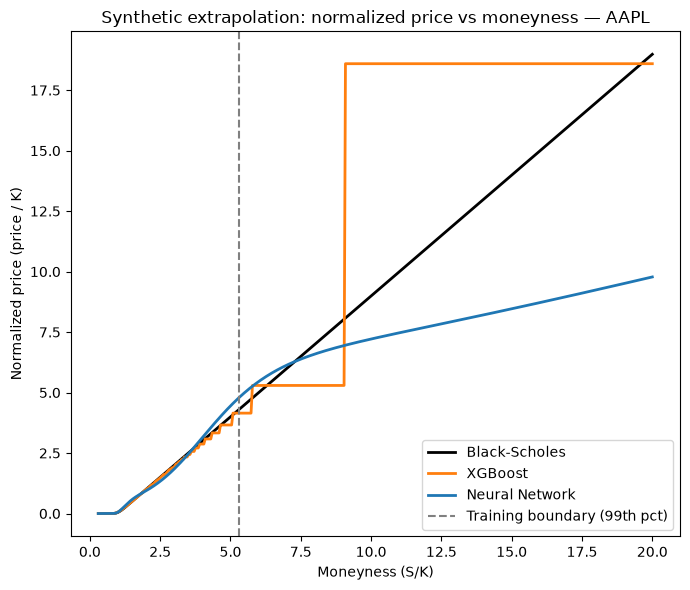

In [52]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(moneyness_grid, bs_price_norm, label="Black-Scholes", color="black", linewidth=2)
ax.plot(moneyness_grid, xgb_pred_norm, label="XGBoost", color="tab:orange", linewidth=2)
ax.plot(moneyness_grid, nn_pred_norm, label="Neural Network", color="tab:blue", linewidth=2)
ax.axvline(train_boundary, color="gray", linestyle="--", linewidth=1.5, label="Training boundary (99th pct)")
ax.set_xlabel("Moneyness (S/K)")
ax.set_ylabel("Normalized price (price / K)")
ax.legend()

ax.set_title("Synthetic extrapolation: normalized price vs moneyness — AAPL")
plt.tight_layout()
plt.savefig("extrapolation_chart_aapl.png", dpi=150)
plt.show()

In [44]:
# check XGBoost prediction at specific moneyness values to see the actual shape
check_points = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0, 4.0, 4.75, 6.0, 8.0, 10.0, 15.0, 20.0]

for m in check_points:
    K_check = S_fixed / m
    X_check = pd.DataFrame({
        "moneyness (S/K)": [m], "T": [T_fixed], "rate": [r_fixed],
        "q": [q_fixed], "volatility": [sigma_fixed]
    })
    pred_norm = np.exp(xgb_model.predict(X_check)[0])   # exp(log(C/K)) = C/K
    pred_price = pred_norm * K_check
    print(f"moneyness={m:>6.2f}  ->  xgb price={pred_price:>8.4f}  normalized={pred_norm:.5f}")

moneyness=  0.50  ->  xgb price=  0.0362  normalized=0.00009
moneyness=  0.80  ->  xgb price=  0.3677  normalized=0.00147
moneyness=  1.00  ->  xgb price= 14.5454  normalized=0.07273
moneyness=  1.20  ->  xgb price= 36.3632  normalized=0.21818
moneyness=  1.50  ->  xgb price= 67.8615  normalized=0.50896
moneyness=  2.00  ->  xgb price=100.0869  normalized=1.00087
moneyness=  3.00  ->  xgb price=130.8093  normalized=1.96214
moneyness=  4.00  ->  xgb price=143.6150  normalized=2.87230
moneyness=  4.75  ->  xgb price=154.1285  normalized=3.66055
moneyness=  6.00  ->  xgb price=176.4980  normalized=5.29494
moneyness=  8.00  ->  xgb price=132.3735  normalized=5.29494
moneyness= 10.00  ->  xgb price=371.9065  normalized=18.59533
moneyness= 15.00  ->  xgb price=247.9377  normalized=18.59533
moneyness= 20.00  ->  xgb price=185.9532  normalized=18.59533


In [45]:
# quanti split diversi produce l'albero oltre il training boundary?
print(np.unique(np.round(xgb_pred_norm[moneyness_grid > 5], 4)))

[ 3.6606  4.1507  5.2949 18.5953]


## XGBoost behaviour on the synthetic extrapolation grid

The synthetic grid fixes the underlying at a realistic level and varies the strike, so
moneyness increases the same way it arises in the data. Up to the training boundary
(moneyness 4.75, the 99th percentile of the training sample) both models track the
Black-Scholes curve closely. Beyond it, the tree ensemble's normalized prediction takes
only four distinct values across the entire grid from moneyness 1 to 20, and the last of
these, 18.60, is returned for every point from moneyness 6 onward: the model has a single
terminal leaf covering that entire region, and any two contracts in it receive an
identical prediction regardless of how far apart their moneyness actually is. This is the
direct consequence of a regression tree's structure -- a finite partition of the input
space into regions of constant prediction -- combined with the scarcity of training data
beyond moneyness 5 (fewer than 1\% of the training sample). The neural network shows no
comparable discontinuity, but its curve also flattens progressively beyond the boundary,
reaching a normalized value of 9.8 at moneyness 20 against 19.1 for Black-Scholes:
extrapolation is smooth rather than a step function, but nothing in the network's
architecture guarantees that it remains accurate.

# SPX

In [46]:
xgb_model_spx = joblib.load("xgb_spx_model.pkl")
nn_model_spx = joblib.load("nn_spx_model.pkl")
nn_scaler_spx = joblib.load("nn_spx_scaler.pkl")

print("xgb expects:", xgb_model_spx.get_booster().feature_names)
print("nn scaler expects", nn_scaler_spx.n_features_in_, "features")
print("all spx models loaded")

xgb expects: ['moneyness (S/K)', 'T', 'rate', 'q', 'volatility']
nn scaler expects 5 features
all spx models loaded


c:\Users\glmar\OneDrive\Bemacs Bocconi\TESI\Thesis\Priced-by-intelligence\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\glmar\OneDrive\Bemacs Bocconi\TESI\Thesis\Priced-by-intelligence\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [47]:
S_fixed_spx = 4274.04          # median SPX level in training
T_fixed_spx = 0.134247
r_fixed_spx = 0.028766
q_fixed_spx = 0.013111
sigma_fixed_spx = 0.140084

moneyness_grid_spx = np.linspace(0.3, 20, 400)
K_grid_spx = S_fixed_spx / moneyness_grid_spx

train_boundary_spx = 4.2     # 99th percentile of training moneyness

print("implied K range:", K_grid_spx.min().round(2), "to", K_grid_spx.max().round(2))

implied K range: 213.7 to 14246.8


In [48]:
# Black-Scholes
d1_spx = (np.log(S_fixed_spx / K_grid_spx) + (r_fixed_spx - q_fixed_spx + 0.5*sigma_fixed_spx**2)*T_fixed_spx) / (sigma_fixed_spx*np.sqrt(T_fixed_spx))
d2_spx = d1_spx - sigma_fixed_spx*np.sqrt(T_fixed_spx)
bs_price_spx = S_fixed_spx*np.exp(-q_fixed_spx*T_fixed_spx)*norm.cdf(d1_spx) - K_grid_spx*np.exp(-r_fixed_spx*T_fixed_spx)*norm.cdf(d2_spx)
bs_price_norm_spx = bs_price_spx / K_grid_spx

# SPX: XGBoost and NN share the same 5 features
X_grid_spx = pd.DataFrame({
    "moneyness (S/K)": moneyness_grid_spx, "T": T_fixed_spx, "rate": r_fixed_spx,
    "q": q_fixed_spx, "volatility": sigma_fixed_spx
})

xgb_pred_norm_spx = np.exp(xgb_model_spx.predict(X_grid_spx))   # exp(log(C/K)) = C/K
nn_pred_norm_spx = np.exp(nn_model_spx.predict(nn_scaler_spx.transform(X_grid_spx)))

print("done")

done


c:\Users\glmar\OneDrive\Bemacs Bocconi\TESI\Thesis\Priced-by-intelligence\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


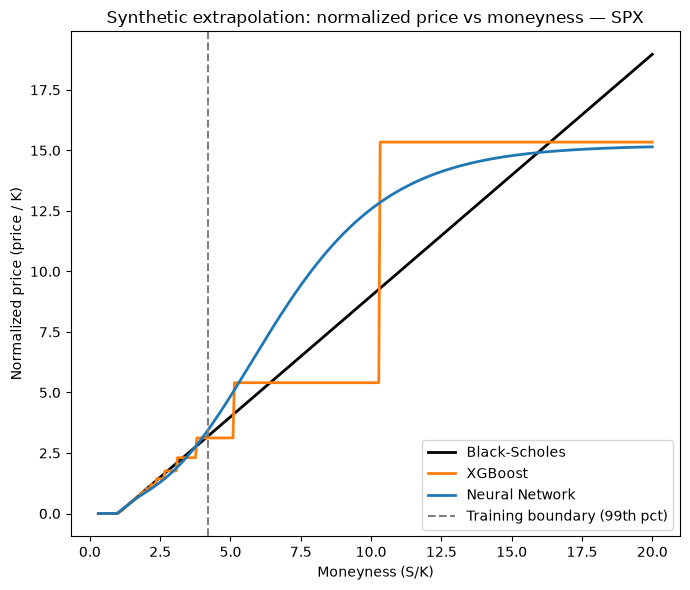

In [53]:
fig, ax = plt.subplots(figsize=(7, 6))

series_spx = [
    ("Black-Scholes", bs_price_norm_spx, "black"),
    ("XGBoost", xgb_pred_norm_spx, "tab:orange"),
    ("Neural Network", nn_pred_norm_spx, "tab:blue"),
]

for label, y, c in series_spx:
    ax.plot(moneyness_grid_spx, y, label=label, color=c, linewidth=2)

ax.axvline(train_boundary_spx, color="gray", linestyle="--", linewidth=1.5, label="Training boundary (99th pct)")
ax.set_xlabel("Moneyness (S/K)")
ax.set_ylabel("Normalized price (price / K)")
ax.legend()

ax.set_title("Synthetic extrapolation: normalized price vs moneyness — SPX")
plt.tight_layout()
plt.savefig("extrapolation_chart_spx.png", dpi=150)
plt.show()

In [50]:
print(np.unique(np.round(xgb_pred_norm_spx[moneyness_grid_spx > train_boundary_spx], 4)))

[ 3.1223  5.4043 15.3415]


On SPX the tree ensemble shows the same mechanism: only three distinct normalized values
are returned across the grid beyond the training boundary, and the last one, 15.34,
covers every point from moneyness 10.3 onward. The neural network's behaviour differs
from the AAPL case in one respect: rather than uniformly trailing the Black-Scholes line,
it temporarily exceeds it between moneyness 6 and 16 before flattening, reaching a
normalized value of roughly 16 at moneyness 20 against 19.1 for Black-Scholes. The
direction of the network's extrapolation error is therefore not consistent across the two
underlyings, while the tree's step-function behaviour is.